# 🔧 Taller — Mantenimiento Predictivo con Sensores IoT
## Modelos Supervisados: Clasificación y Regresión

**Curso:** Aprendizaje Automático  
**Dataset:** AI4I 2020 Predictive Maintenance Dataset (basado en UCI ML Repository)  
**Dominio:** Sensores industriales IoT — Industria 4.0  

---

## 📋 Descripción del Problema

En entornos industriales modernos, sensores IoT recopilan datos en tiempo real sobre
el estado de las máquinas. Este taller aplica modelos supervisados para dos problemas:

| # | Problema | Tipo | Variable objetivo |
|---|---|---|---|
| A | ¿Fallará la máquina? | **Clasificación binaria** | `Machine failure` (0/1) |
| B | ¿Cuánto se ha desgastado la herramienta? | **Regresión** | `Tool wear [min]` |

### Variables del dataset
| Variable | Tipo | Descripción |
|---|---|---|
| `Type` | Categórico | Calidad: L (baja), M (media), H (alta) |
| `Air temperature [K]` | Sensor | Temperatura ambiental |
| `Process temperature [K]` | Sensor | Temperatura del proceso |
| `Rotational speed [rpm]` | Sensor | Velocidad de rotación |
| `Torque [Nm]` | Sensor | Par de torsión |
| `Tool wear [min]` | Sensor / **Target B** | Desgaste acumulado |
| `Machine failure` | **Target A** | Fallo detectado (0=No, 1=Sí) |

---

## ⚠️ Precaución: Data Leakage

> **Problema A (clasificación):** `Tool wear [min]` se puede usar como feature
> porque es una lectura de sensor independiente del evento de fallo.
>
> **Problema B (regresión):** `Machine failure` se **excluye** como feature porque
> en producción real no se conoce antes de hacer la predicción.
>
> Un modelo con métricas perfectas (R²=1.0 o F1=1.0) es señal de data leakage,
> **no** de un buen modelo.

---

## 0. Importaciones y Configuración

In [1]:
# ── Librerías generales ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento ──────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.impute import SimpleImputer

# ── Modelos de clasificación ──────────────────────────────────────────────────
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ── Modelos de regresión ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# ── Métricas ──────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

# ── Configuración visual ──────────────────────────────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print('Librerías importadas correctamente.')

Librerías importadas correctamente.


## 1. Carga del Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/S2AA/data/ai4i_predictive_maintenance.csv')

Mounted at /content/drive


---
## 2. Análisis Exploratorio de Datos (EDA)

El EDA permite entender la distribución de variables, detectar outliers,
identificar correlaciones y fundamentar las decisiones de preprocesamiento.

In [3]:
# ── 2.1 Resumen estadístico ───────────────────────────────────────────────────
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print()
df.describe()

=== Tipos de datos ===
UDI                          int64
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
dtype: object

=== Valores nulos por columna ===
UDI                        0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
dtype: int64



,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5000.5000,300.0249,310.0231,1534.0111,40.1101,125.4727,0.0336
std,2886.8957,1.9998,2.2504,179.6251,9.9526,73.5282,0.1802
min,1.0000,292.2000,301.0000,1000.0000,3.0000,0.0000,0.0000
25%,2500.7500,298.7000,308.5000,1411.0000,33.4000,61.0000,0.0000
50%,5000.5000,300.0000,310.0000,1534.0000,40.1000,126.0000,0.0000
75%,7500.2500,301.4000,311.6000,1658.0000,46.9000,189.0000,0.0000
max,10000.0000,309.0000,320.5000,2205.0000,75.4000,253.0000,1.0000


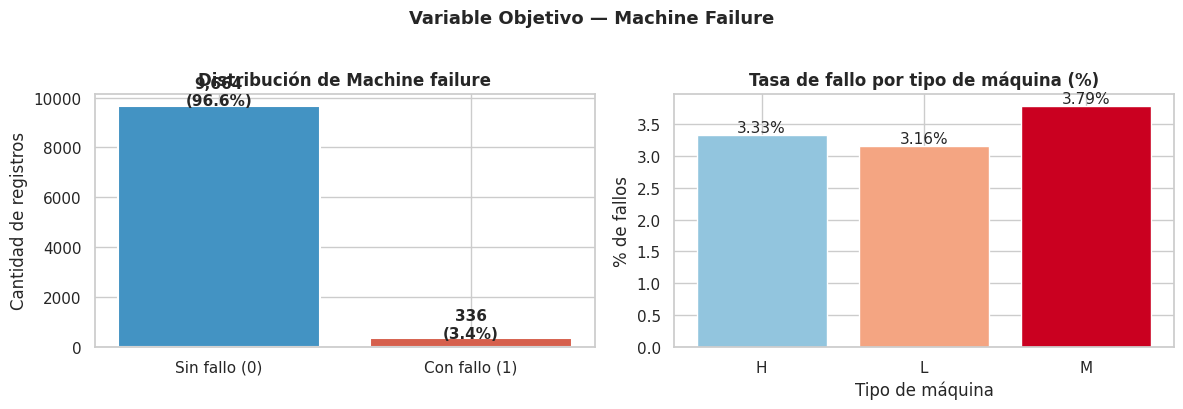

ADVERTENCIA: Dataset desbalanceado (~3.4% positivos).
Usar F1-score y AUC-ROC como métricas principales, NO accuracy.


In [4]:
# ── 2.2 Distribución de la variable objetivo ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Machine failure'].value_counts()
axes[0].bar(['Sin fallo (0)', 'Con fallo (1)'], counts.values,
            color=['#4393c3', '#d6604d'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribución de Machine failure', fontweight='bold')
axes[0].set_ylabel('Cantidad de registros')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

type_fail = df.groupby('Type')['Machine failure'].mean() * 100
axes[1].bar(type_fail.index, type_fail.values,
            color=['#92c5de', '#f4a582', '#ca0020'], edgecolor='white')
axes[1].set_title('Tasa de fallo por tipo de máquina (%)', fontweight='bold')
axes[1].set_ylabel('% de fallos')
axes[1].set_xlabel('Tipo de máquina')
for i, (tipo, val) in enumerate(type_fail.items()):
    axes[1].text(i, val + 0.05, f'{val:.2f}%', ha='center', fontsize=11)

plt.suptitle('Variable Objetivo — Machine Failure', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('ADVERTENCIA: Dataset desbalanceado (~3.4% positivos).')
print('Usar F1-score y AUC-ROC como métricas principales, NO accuracy.')

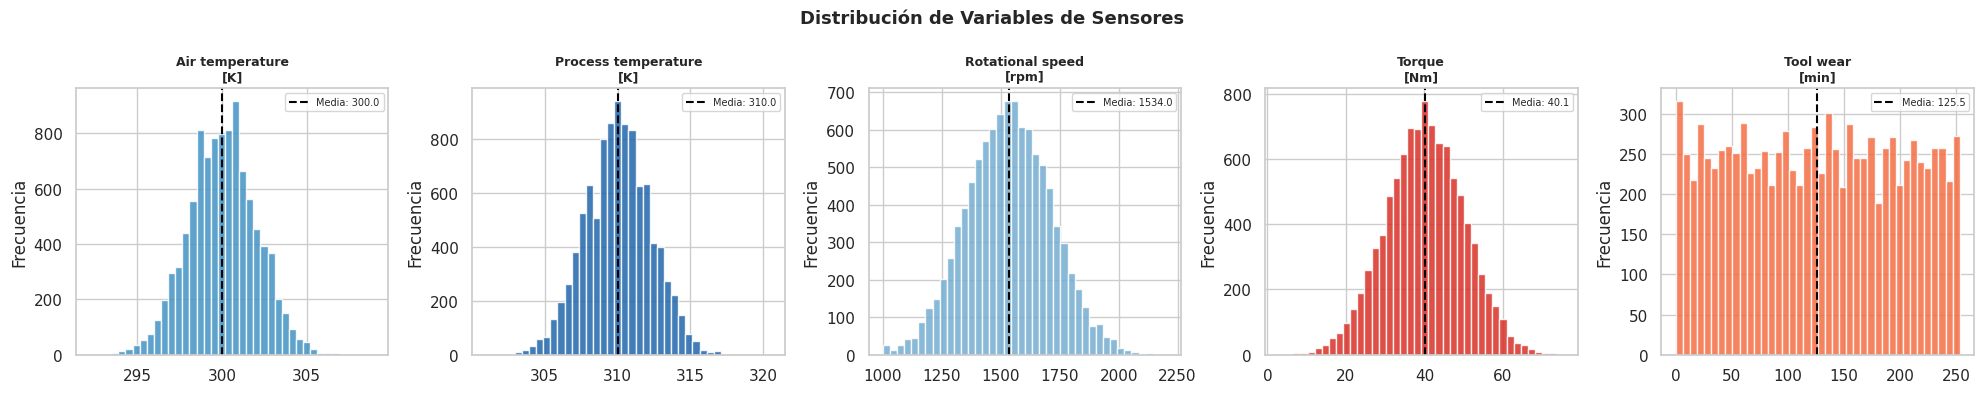

In [5]:
# ── 2.3 Histogramas de variables numéricas ────────────────────────────────────
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colores = ['#4393c3', '#2166ac', '#74add1', '#d73027', '#f46d43']

for ax, col, color in zip(axes, num_cols, colores):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace(' [', '\n['), fontsize=9, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.axvline(df[col].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f'Media: {df[col].mean():.1f}')
    ax.legend(fontsize=7)

plt.suptitle('Distribución de Variables de Sensores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

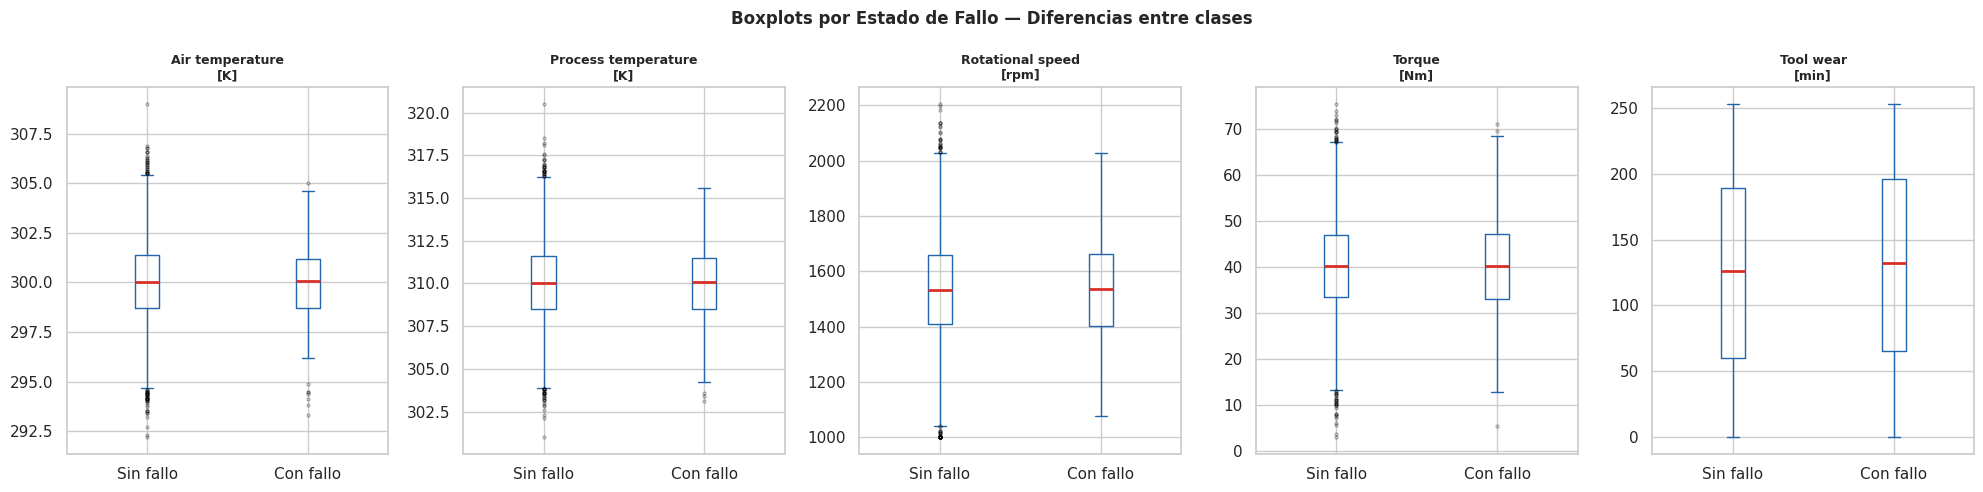

Diferencias en la distribución entre clase 0 y 1 indican poder predictivo.


In [6]:
# ── 2.4 Boxplots por estado de fallo ─────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, col in zip(axes, num_cols):
    data_0 = df[df['Machine failure']==0][col]
    data_1 = df[df['Machine failure']==1][col]
    ax.boxplot([data_0, data_1], labels=['Sin fallo', 'Con fallo'],
               boxprops=dict(color='#2166ac'),
               medianprops=dict(color='#d73027', linewidth=2),
               whiskerprops=dict(color='#2166ac'),
               capprops=dict(color='#2166ac'),
               flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(col.replace(' [', '\n['), fontsize=9, fontweight='bold')

plt.suptitle('Boxplots por Estado de Fallo — Diferencias entre clases',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Diferencias en la distribución entre clase 0 y 1 indican poder predictivo.')

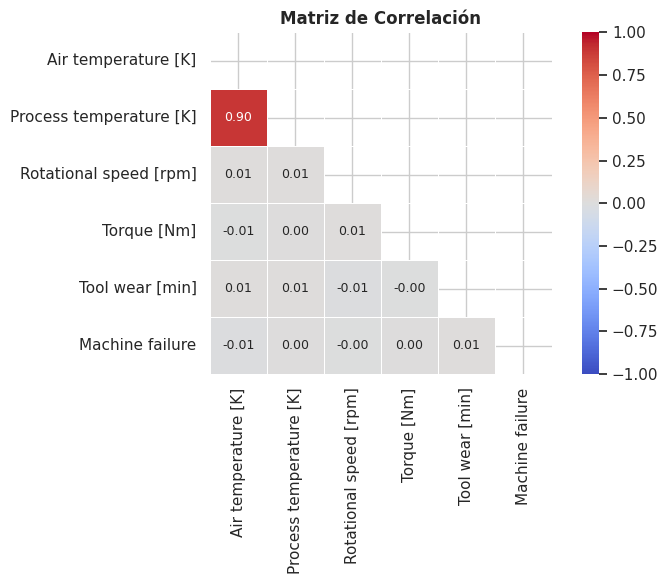

Variables con mayor correlación con Machine failure:
Tool wear [min]           0.0096
Air temperature [K]       0.0089
Torque [Nm]               0.0042
Rotational speed [rpm]    0.0007
Process temperature [K]   0.0000


In [7]:
# ── 2.5 Matriz de correlación ─────────────────────────────────────────────────
corr_cols = num_cols + ['Machine failure']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, mask=mask, annot_kws={'size': 9})
ax.set_title('Matriz de Correlación', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print('Variables con mayor correlación con Machine failure:')
corr_target = corr_matrix['Machine failure'].drop('Machine failure').abs().sort_values(ascending=False)
print(corr_target.to_string())

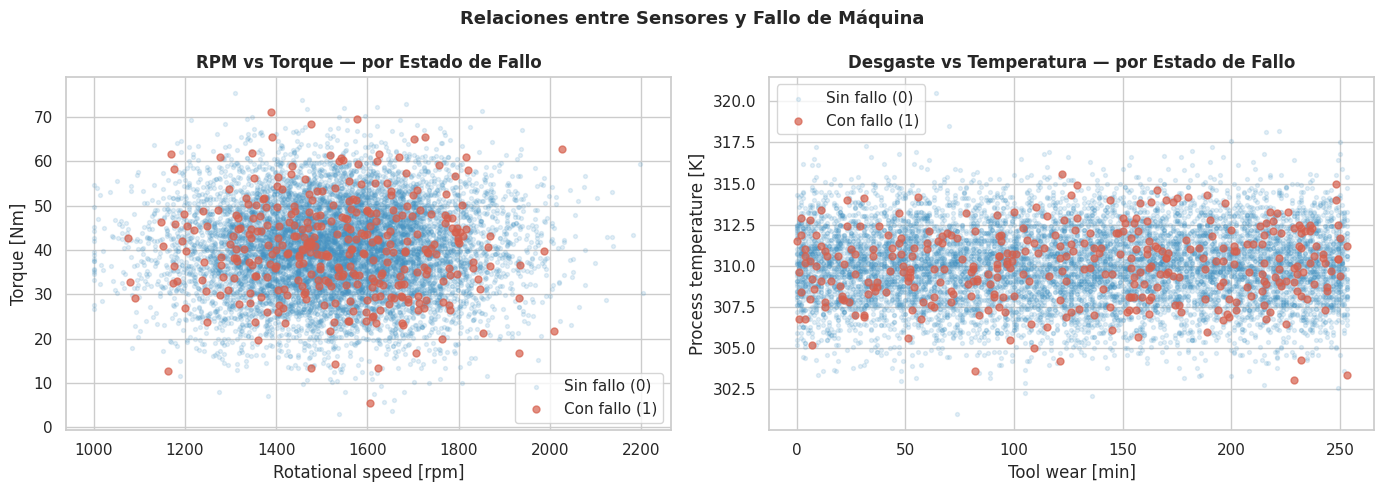

In [8]:
# ── 2.6 Scatter: relaciones entre sensores coloreado por fallo ────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

no_fail = df[df['Machine failure'] == 0]
fail    = df[df['Machine failure'] == 1]

axes[0].scatter(no_fail['Rotational speed [rpm]'], no_fail['Torque [Nm]'],
                alpha=0.15, s=8, color='#4393c3', label='Sin fallo (0)')
axes[0].scatter(fail['Rotational speed [rpm]'], fail['Torque [Nm]'],
                alpha=0.7, s=25, color='#d6604d', label='Con fallo (1)', zorder=5)
axes[0].set_xlabel('Rotational speed [rpm]')
axes[0].set_ylabel('Torque [Nm]')
axes[0].set_title('RPM vs Torque — por Estado de Fallo', fontweight='bold')
axes[0].legend()

axes[1].scatter(no_fail['Tool wear [min]'], no_fail['Process temperature [K]'],
                alpha=0.15, s=8, color='#4393c3', label='Sin fallo (0)')
axes[1].scatter(fail['Tool wear [min]'], fail['Process temperature [K]'],
                alpha=0.7, s=25, color='#d6604d', label='Con fallo (1)', zorder=5)
axes[1].set_xlabel('Tool wear [min]')
axes[1].set_ylabel('Process temperature [K]')
axes[1].set_title('Desgaste vs Temperatura — por Estado de Fallo', fontweight='bold')
axes[1].legend()

plt.suptitle('Relaciones entre Sensores y Fallo de Máquina', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Preprocesamiento

### Justificación de decisiones:

| Paso | Decisión | Justificación |
|---|---|---|
| Codificación `Type` | Label Encoding L=0, M=1, H=2 | Variable ordinal: L < M < H en calidad |
| Eliminar `UDI` | Sí | Es un identificador sin valor predictivo |
| Escalado | StandardScaler (fit solo en train) | SVM es sensible a la escala; evita data leakage del scaler |
| Valores nulos | SimpleImputer (mediana) | Robustez ante outliers |
| División | 80/20 con `stratify=y` | Preserva la proporción de clases desbalanceadas |

In [9]:
# ── 3.1 Codificación ordinal de Type ─────────────────────────────────────────
type_map = {'L': 0, 'M': 1, 'H': 2}
df['Type_encoded'] = df['Type'].map(type_map)

print('Codificación Type:')
print(df.groupby('Type')['Type_encoded'].first().to_string())

# ── 3.2 Definición de features ────────────────────────────────────────────────

# PROBLEMA A — Clasificación
# Target: Machine failure
# Features: todos los sensores + tipo; excluye UDI (ID) y Machine failure (target)
features_clf = [
    'Type_encoded',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'    # sensor independiente, NO es data leakage
]
X_clf = df[features_clf].copy()
y_clf = df['Machine failure'].copy()

# PROBLEMA B — Regresión
# Target: Tool wear [min]
# Machine failure se EXCLUYE: en produccion real no se conoce antes de predecir
features_reg = [
    'Type_encoded',
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]'
]
X_reg = df[features_reg].copy()
y_reg = df['Tool wear [min]'].copy()

# ── 3.3 División 80/20 ────────────────────────────────────────────────────────
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.20, random_state=42, stratify=y_clf)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=42)

# ── 3.4 Imputación + Escalado ─────────────────────────────────────────────────
# IMPORTANTE: fit_transform en train, solo transform en test
# Si hiciéramos fit en todo el dataset, el escalador 'vería' el test => data leakage
imputer_c = SimpleImputer(strategy='median')
scaler_c  = StandardScaler()
X_train_c_sc = scaler_c.fit_transform(imputer_c.fit_transform(X_train_c))
X_test_c_sc  = scaler_c.transform(imputer_c.transform(X_test_c))

imputer_r = SimpleImputer(strategy='median')
scaler_r  = StandardScaler()
X_train_r_sc = scaler_r.fit_transform(imputer_r.fit_transform(X_train_r))
X_test_r_sc  = scaler_r.transform(imputer_r.transform(X_test_r))

print()
print('Preprocesamiento completado.')
print(f'  Clasificacion — Train: {X_train_c_sc.shape}  |  Test: {X_test_c_sc.shape}')
print(f'  Regresion     — Train: {X_train_r_sc.shape}  |  Test: {X_test_r_sc.shape}')
print(f'  Balance clases train : {y_train_c.mean()*100:.2f}% con fallo')

Codificación Type:
Type
H    2
L    0
M    1

Preprocesamiento completado.
  Clasificacion — Train: (8000, 6)  |  Test: (2000, 6)
  Regresion     — Train: (8000, 5)  |  Test: (2000, 5)
  Balance clases train : 3.36% con fallo


---
## 4. Problema A — Clasificación: Predicción de Fallo de Máquina

**Variable objetivo:** `Machine failure` (0 = Sin fallo, 1 = Con fallo)  
**Métrica principal:** F1-score y AUC-ROC  

> Con clases desbalanceadas la *accuracy* es engañosa: un modelo que predice
> siempre '0' obtendría 96.6% de accuracy sin detectar ningún fallo.
> Por eso usamos **F1-score** (equilibrio precision/recall) y **AUC-ROC**.

### 4.1 Modelo 1 — Árbol de Decisión

**Fundamento:** divide el espacio de features con reglas if-then aprendidas de los datos,
minimizando impureza Gini en cada nodo. Altamente interpretable — permite ver exactamente
qué valores de sensor activan la predicción de fallo.

**Hiperparámetros seleccionados:**
- `max_depth=8`: limita la profundidad para evitar sobreajuste (memorización del train)
- `min_samples_leaf=20`: una hoja debe tener al menos 20 muestras → reglas más generales
- `class_weight='balanced'`: compensa el desbalance 96.6% / 3.4% automáticamente

In [10]:
dt = DecisionTreeClassifier(
    max_depth=8, min_samples_leaf=20,
    class_weight='balanced', random_state=42
)
dt.fit(X_train_c_sc, y_train_c)

y_pred_dt = dt.predict(X_test_c_sc)
y_prob_dt = dt.predict_proba(X_test_c_sc)[:, 1]

# Detectar overfitting: comparar F1 train vs test
f1_train_dt = f1_score(y_train_c, dt.predict(X_train_c_sc))
f1_test_dt  = f1_score(y_test_c, y_pred_dt)

print('ARBOL DE DECISION — Resultados en Test')
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_dt):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_dt):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_dt):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_dt):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_dt):.4f}')
print(f'  F1 Train  : {f1_train_dt:.4f}  |  F1 Test: {f1_test_dt:.4f}  |  Gap: {f1_train_dt-f1_test_dt:.4f}')
print()
print(classification_report(y_test_c, y_pred_dt, target_names=['Sin fallo','Con fallo']))

ARBOL DE DECISION — Resultados en Test
  Accuracy  : 0.8885
  Precision : 0.0244
  Recall    : 0.0597
  F1-Score  : 0.0346
  AUC-ROC   : 0.5018
  F1 Train  : 0.1323  |  F1 Test: 0.0346  |  Gap: 0.0977

              precision    recall  f1-score   support

   Sin fallo       0.97      0.92      0.94      1933
   Con fallo       0.02      0.06      0.03        67

    accuracy                           0.89      2000
   macro avg       0.50      0.49      0.49      2000
weighted avg       0.93      0.89      0.91      2000



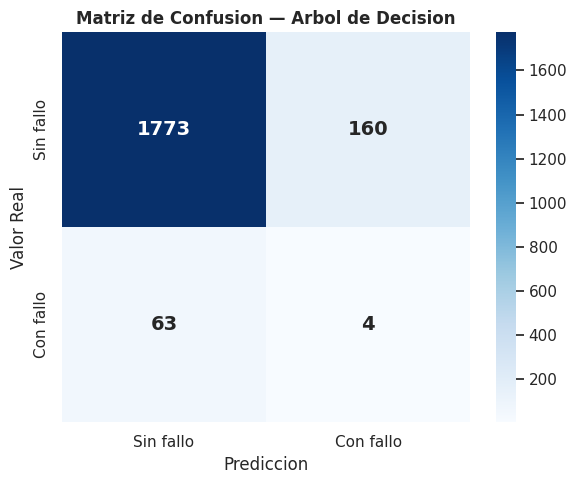

TN=1773 | FP=160 | FN=63 | TP=4
Falsos negativos (fallos no detectados): 63 — criticos en contexto industrial


In [11]:
# Visualizar la matriz de confusion del Arbol de Decision como heatmap
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_c, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sin fallo','Con fallo'],
            yticklabels=['Sin fallo','Con fallo'],
            ax=ax, annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prediccion'); ax.set_ylabel('Valor Real')
ax.set_title('Matriz de Confusion — Arbol de Decision', fontweight='bold')
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn} | FP={fp} | FN={fn} | TP={tp}')
print(f'Falsos negativos (fallos no detectados): {fn} — criticos en contexto industrial')

#### Visualización del Árbol de Decisión

Los primeros 3 niveles del árbol revelan las **reglas aprendidas automáticamente**:
qué sensores y umbrales el modelo usa para decidir si habrá fallo.
Los nodos con mayor proporción de "Con fallo" aparecen en naranja/rojo (filled=True).

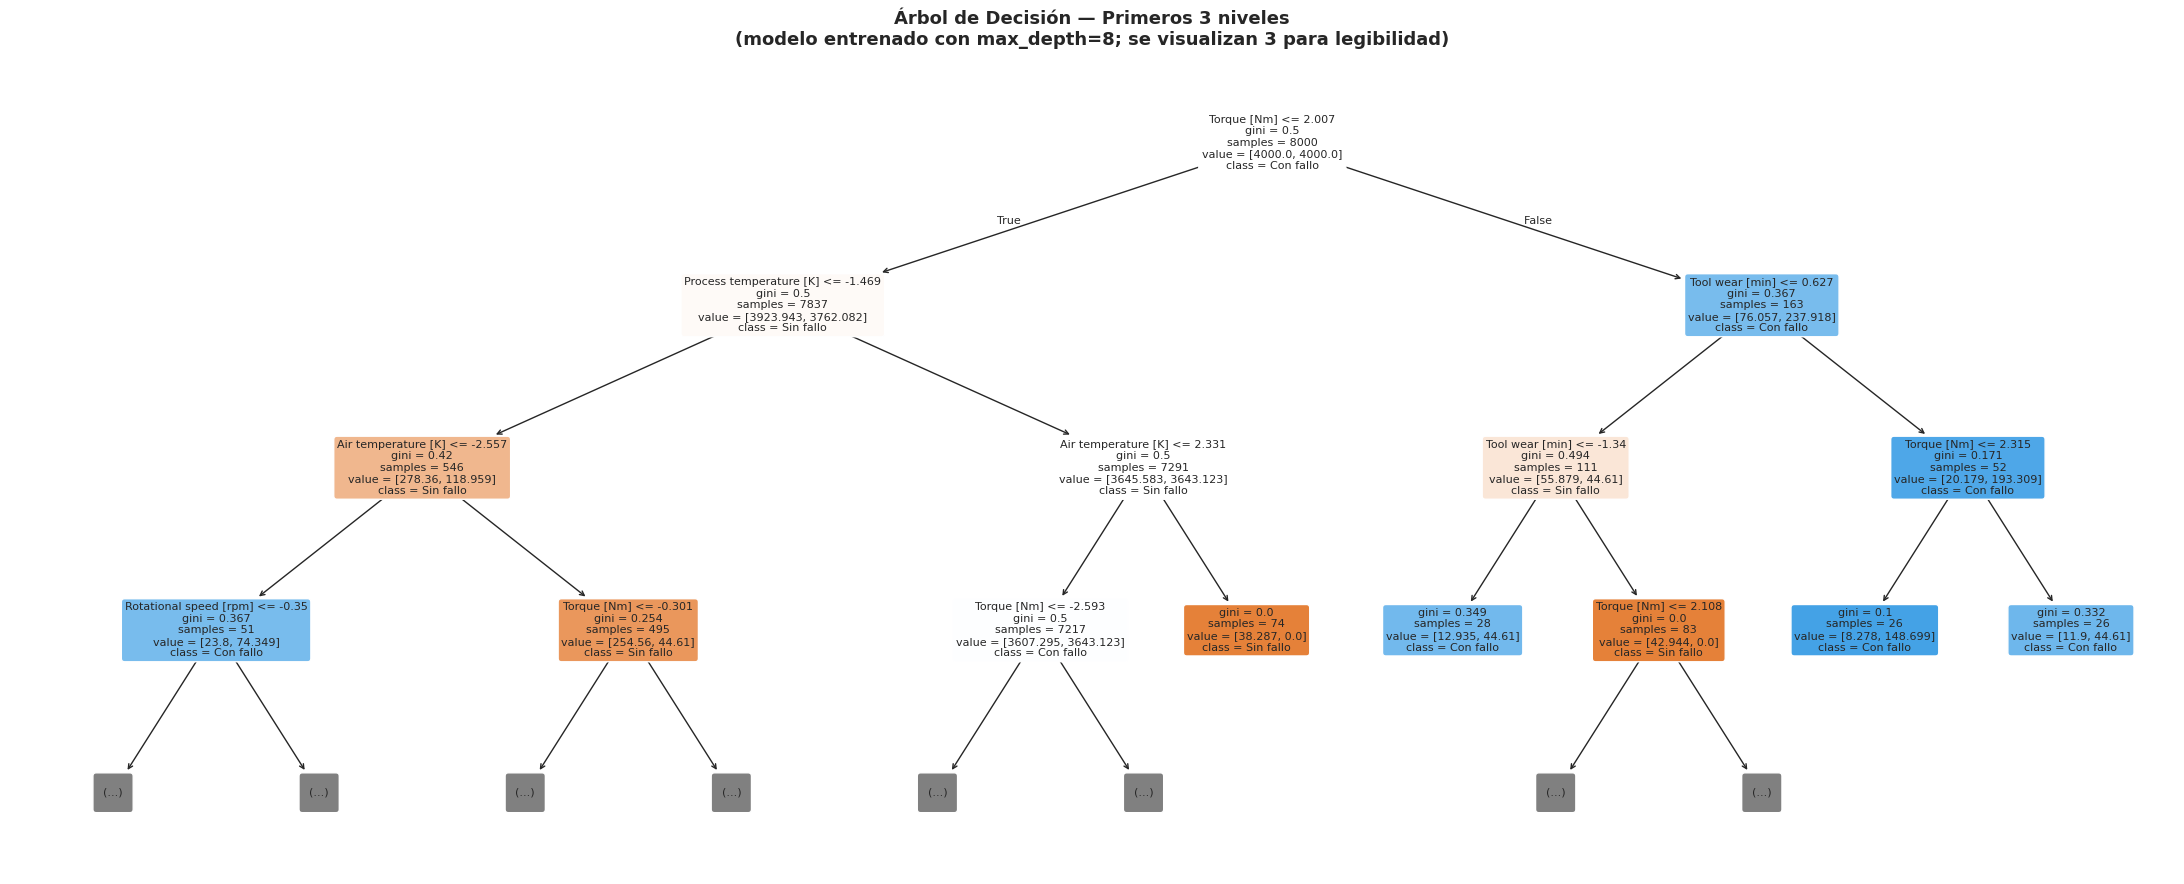

=== IMPACTO DE max_depth EN SOBREAJUSTE ===
   max_depth    F1 Train     F1 Test     Gap (Overfitting)
----------------------------------------------------------
           2      0.0810      0.0500               +0.0310
           3      0.0698      0.0650               +0.0049
           5      0.0713      0.0645               +0.0068
           8      0.1323      0.0346               +0.0977 ← elegido
          15      0.1156      0.0635               +0.0521
  Sin límite      0.2189      0.0606               +0.1583

→ max_depth=8 equilibra complejidad y generalización.
→ Sin límite: gap grande = árbol memoriza el conjunto de entrenamiento.


In [12]:
# ── Visualización del árbol (primeros 3 niveles) ─────────────────────────────
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt,
    max_depth=3,
    feature_names=features_clf,
    class_names=['Sin fallo', 'Con fallo'],
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=True,
    proportion=False,
    ax=ax
)
ax.set_title(
    'Árbol de Decisión — Primeros 3 niveles\n'
    '(modelo entrenado con max_depth=8; se visualizan 3 para legibilidad)',
    fontsize=13, fontweight='bold', pad=12
)
plt.tight_layout()
plt.show()

# ── Análisis profundidad vs overfitting ───────────────────────────────────────
print('=== IMPACTO DE max_depth EN SOBREAJUSTE ===')
print(f'{"max_depth":>12}  {"F1 Train":>10}  {"F1 Test":>10}  {"Gap (Overfitting)":>20}')
print('-'*58)
for depth in [2, 3, 5, 8, 15, None]:
    dt_tmp = DecisionTreeClassifier(
        max_depth=depth, min_samples_leaf=20,
        class_weight='balanced', random_state=42)
    dt_tmp.fit(X_train_c_sc, y_train_c)
    f1_tr = f1_score(y_train_c, dt_tmp.predict(X_train_c_sc))
    f1_te = f1_score(y_test_c,  dt_tmp.predict(X_test_c_sc))
    lbl = str(depth) if depth is not None else 'Sin límite'
    marker = ' ← elegido' if depth == 8 else ''
    print(f'{lbl:>12}  {f1_tr:>10.4f}  {f1_te:>10.4f}  {f1_tr-f1_te:>+20.4f}{marker}')
print()
print('→ max_depth=8 equilibra complejidad y generalización.')
print('→ Sin límite: gap grande = árbol memoriza el conjunto de entrenamiento.')

### 4.2 Modelo 2 — SVM (Support Vector Machine)

**Fundamento:** el SVM busca el hiperplano de máximo margen que separa las clases.
Con kernel **RBF (Radial Basis Function)** puede capturar fronteras de decisión
no lineales, fundamentales en datos de sensores industriales donde los fallos
ocurren en combinaciones específicas de temperatura, torque y RPM.

#### Justificación del kernel RBF sobre alternativas

| Kernel | Supuesto | ¿Aplica aquí? |
|--------|----------|--------------|
| **Lineal** | Las clases son separables con una línea/plano | ❌ Los fallos dependen de interacciones no lineales entre sensores |
| **Polinomial** | Las relaciones son polinómicas de grado fijo | ❌ Propenso a overfitting con datos tan desbalanceados (3.4% fallos) |
| **RBF** ✅ | Mapea a espacio de alta dimensión con distancias gaussianas | ✅ Captura patrones locales complejos; efectivo tras aplicar `StandardScaler` |

#### Hiperparámetro C — Regularización del margen

| C | Efecto | Riesgo |
|---|--------|--------|
| **0.1** | Margen amplio, más tolerancia a errores | Underfitting — pierde fallos reales |
| **1.0** | Balance estándar | Punto de partida recomendado |
| **10.0** | Margen estrecho, ajusta cada punto | Posible overfitting |

> Se evaluarán C ∈ {0.1, 1.0, 10.0} y se seleccionará el mejor por **F1-Score**,
> ya que con clases desbalanceadas el F1 es más informativo que la accuracy.

In [25]:
# ── 4.2a Búsqueda del mejor C — SVM RBF ──────────────────────────────────────
print('=== BÚSQUEDA DE HIPERPARÁMETRO C — SVM (kernel RBF) ===')
cols = ['C', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']
header = f"{cols[0]:>6}  {cols[1]:>10}  {cols[2]:>10}  {cols[3]:>8}  {cols[4]:>8}  {cols[5]:>9}"
print(header)
print('-'*60)

resultados_c = {}
for C_val in [0.1, 1.0, 10.0]:
    svm_tmp = SVC(kernel='rbf', C=C_val, gamma='scale',
                  class_weight='balanced', probability=True, random_state=42)
    svm_tmp.fit(X_train_c_sc, y_train_c)
    y_p   = svm_tmp.predict(X_test_c_sc)
    y_prb = svm_tmp.predict_proba(X_test_c_sc)[:, 1]
    resultados_c[C_val] = {
        'acc': accuracy_score(y_test_c, y_p),
        'pre': precision_score(y_test_c, y_p),
        'rec': recall_score(y_test_c, y_p),
        'f1' : f1_score(y_test_c, y_p),
        'auc': roc_auc_score(y_test_c, y_prb),
        'pred': y_p, 'prob': y_prb
    }
    print(f'{C_val:>6}  ',
          f'{resultados_c[C_val]["acc"]:>10.4f}  ',
          f'{resultados_c[C_val]["pre"]:>10.4f}  ',
          f'{resultados_c[C_val]["rec"]:>8.4f}  ',
          f'{resultados_c[C_val]["f1"]:>8.4f}  ',
          f'{resultados_c[C_val]["auc"]:>9.4f}')
best_C = max(resultados_c, key=lambda c: resultados_c[c]['f1'])
print('Mejor C por F1-Score: C=' + str(best_C) + '  (F1=' + str(round(resultados_c[best_C]["f1"], 4)) + ')')
print(f'  Interpretación: C={best_C} ofrece el mejor equilibrio Precision/Recall')
print(f'  para este dataset con alta tasa de desbalance (3.4% fallos).')

# ── 4.2b Modelo SVM final con el mejor C ──────────────────────────────────────
svm = SVC(kernel='rbf', C=best_C, gamma='scale',
          class_weight='balanced', probability=True, random_state=42)
svm.fit(X_train_c_sc, y_train_c)

y_pred_svm = svm.predict(X_test_c_sc)
y_prob_svm = svm.predict_proba(X_test_c_sc)[:, 1]

rec_val = recall_score(y_test_c, y_pred_svm)

print('=== SVM (RBF, C=' + str(best_C) + ') - Resultados finales en Test ===')
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_svm):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_svm):.4f}')
print(f'  Recall    : {rec_val:.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_svm):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_svm):.4f}')
print()
print(classification_report(y_test_c, y_pred_svm, target_names=['Sin fallo','Con fallo']))
print('Interpretación del SVM:')
print(f'  Recall={rec_val:.4f}: de cada 100 fallos reales, el SVM detecta')
print(f'  aproximadamente {round(rec_val * 100)} casos.')
print('  En contexto industrial: un Recall alto es crítico para no dejar')
print('  fallos sin detectar, aunque esto genere más falsas alarmas (FP).')

=== BÚSQUEDA DE HIPERPARÁMETRO C — SVM (kernel RBF) ===
     C    Accuracy   Precision    Recall        F1    AUC-ROC
------------------------------------------------------------
   0.1       0.5850       0.0409     0.5075     0.0757      0.4415
   1.0       0.5980       0.0365     0.4328     0.0673      0.4324
  10.0       0.6405       0.0382     0.4030     0.0699      0.4441
Mejor C por F1-Score: C=0.1  (F1=0.0757)
  Interpretación: C=0.1 ofrece el mejor equilibrio Precision/Recall
  para este dataset con alta tasa de desbalance (3.4% fallos).
=== SVM (RBF, C=0.1) - Resultados finales en Test ===
  Accuracy  : 0.5850
  Precision : 0.0409
  Recall    : 0.5075
  F1-Score  : 0.0757
  AUC-ROC   : 0.4415

              precision    recall  f1-score   support

   Sin fallo       0.97      0.59      0.73      1933
   Con fallo       0.04      0.51      0.08        67

    accuracy                           0.58      2000
   macro avg       0.51      0.55      0.40      2000
weighted avg    

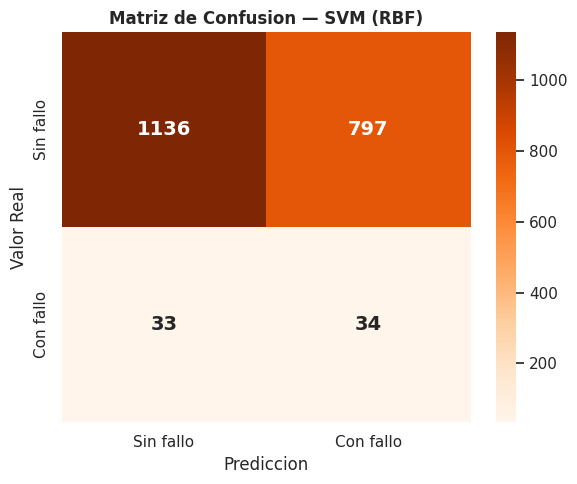

In [26]:
# Visualizar la matriz de confusion del SVM como heatmap
fig, ax = plt.subplots(figsize=(6, 5))
cm_svm = confusion_matrix(y_test_c, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Sin fallo','Con fallo'],
            yticklabels=['Sin fallo','Con fallo'],
            ax=ax, annot_kws={'size':14,'weight':'bold'})
ax.set_xlabel('Prediccion'); ax.set_ylabel('Valor Real')
ax.set_title('Matriz de Confusion — SVM (RBF)', fontweight='bold')
plt.tight_layout(); plt.show()

### 4.3 Modelo 3 — Random Forest

**Fundamento:** ensemble de árboles entrenados sobre subconjuntos aleatorios
de features y muestras (bagging). Reduce varianza respecto a un árbol solo
y genera importancia de variables de forma nativa.  
**Hiperparámetros:** `n_estimators=200`, `max_depth=10`, `class_weight='balanced'`.

In [27]:
# Entrenar Random Forest y evaluar metricas en test
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_leaf=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_c_sc, y_train_c)

y_pred_rf = rf.predict(X_test_c_sc)
y_prob_rf = rf.predict_proba(X_test_c_sc)[:, 1]

print('RANDOM FOREST — Resultados en Test')
print(f'  Accuracy  : {accuracy_score(y_test_c, y_pred_rf):.4f}')
print(f'  Precision : {precision_score(y_test_c, y_pred_rf):.4f}')
print(f'  Recall    : {recall_score(y_test_c, y_pred_rf):.4f}')
print(f'  F1-Score  : {f1_score(y_test_c, y_pred_rf):.4f}')
print(f'  AUC-ROC   : {roc_auc_score(y_test_c, y_prob_rf):.4f}')
print()
print(classification_report(y_test_c, y_pred_rf, target_names=['Sin fallo','Con fallo']))

RANDOM FOREST — Resultados en Test
  Accuracy  : 0.9555
  Precision : 0.0769
  Recall    : 0.0299
  F1-Score  : 0.0430
  AUC-ROC   : 0.5273

              precision    recall  f1-score   support

   Sin fallo       0.97      0.99      0.98      1933
   Con fallo       0.08      0.03      0.04        67

    accuracy                           0.96      2000
   macro avg       0.52      0.51      0.51      2000
weighted avg       0.94      0.96      0.95      2000



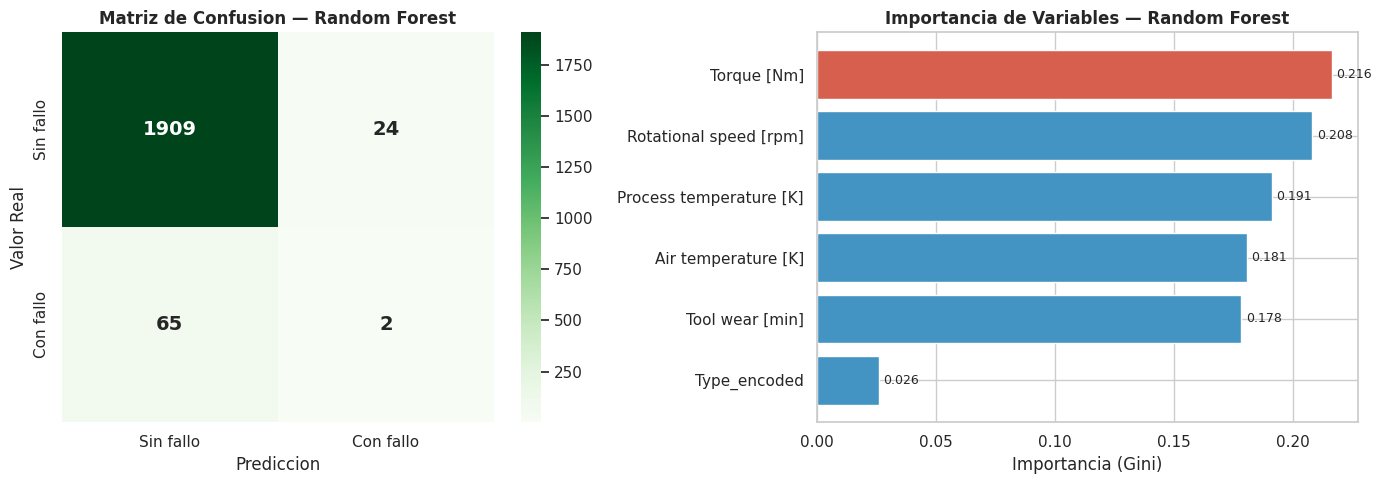

Variable mas importante: Torque [Nm]


In [28]:
# Visualizar matriz de confusion e importancia de variables del Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_rf = confusion_matrix(y_test_c, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Sin fallo','Con fallo'],
            yticklabels=['Sin fallo','Con fallo'],
            ax=axes[0], annot_kws={'size':14,'weight':'bold'})
axes[0].set_xlabel('Prediccion'); axes[0].set_ylabel('Valor Real')
axes[0].set_title('Matriz de Confusion — Random Forest', fontweight='bold')

importancias = pd.Series(rf.feature_importances_, index=features_clf).sort_values()
colores_imp  = ['#d6604d' if v == importancias.max() else '#4393c3' for v in importancias.values]
axes[1].barh(importancias.index, importancias.values, color=colores_imp, edgecolor='white')
axes[1].set_title('Importancia de Variables — Random Forest', fontweight='bold')
axes[1].set_xlabel('Importancia (Gini)')
for i, v in enumerate(importancias.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()
print('Variable mas importante:', importancias.idxmax())

---
## 5. Comparación Experimental — Clasificación

In [29]:
# Consolidar metricas de los 3 modelos en una tabla comparativa
resultados_clf = {
    'Arbol Decision': dict(
        Accuracy=accuracy_score(y_test_c, y_pred_dt),
        Precision=precision_score(y_test_c, y_pred_dt),
        Recall=recall_score(y_test_c, y_pred_dt),
        F1=f1_score(y_test_c, y_pred_dt),
        AUC=roc_auc_score(y_test_c, y_prob_dt)),
    'SVM RBF': dict(
        Accuracy=accuracy_score(y_test_c, y_pred_svm),
        Precision=precision_score(y_test_c, y_pred_svm),
        Recall=recall_score(y_test_c, y_pred_svm),
        F1=f1_score(y_test_c, y_pred_svm),
        AUC=roc_auc_score(y_test_c, y_prob_svm)),
    'Random Forest': dict(
        Accuracy=accuracy_score(y_test_c, y_pred_rf),
        Precision=precision_score(y_test_c, y_pred_rf),
        Recall=recall_score(y_test_c, y_pred_rf),
        F1=f1_score(y_test_c, y_pred_rf),
        AUC=roc_auc_score(y_test_c, y_prob_rf)),
}

df_clf_res = pd.DataFrame(resultados_clf).T
print('=== TABLA RESUMEN — CLASIFICACION ===')
print(df_clf_res.round(4).to_string())
print()
print(f'Mejor F1  : {df_clf_res["F1"].idxmax()} ({df_clf_res["F1"].max():.4f})')
print(f'Mejor AUC : {df_clf_res["AUC"].idxmax()} ({df_clf_res["AUC"].max():.4f})')

=== TABLA RESUMEN — CLASIFICACION ===
                Accuracy  Precision  Recall     F1    AUC
Arbol Decision    0.8885     0.0244  0.0597 0.0346 0.5018
SVM RBF           0.5850     0.0409  0.5075 0.0757 0.4415
Random Forest     0.9555     0.0769  0.0299 0.0430 0.5273

Mejor F1  : SVM RBF (0.0757)
Mejor AUC : Random Forest (0.5273)


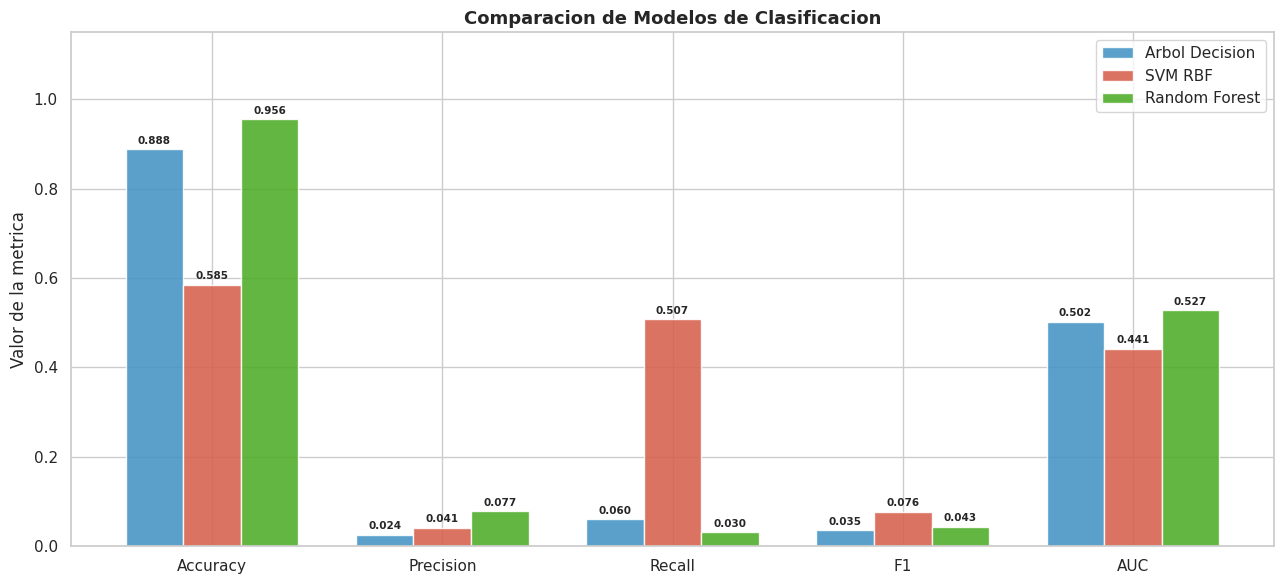

In [30]:
# Barplot agrupado comparando las 5 metricas entre los 3 modelos
metricas_names = ['Accuracy','Precision','Recall','F1','AUC']
modelos_names  = list(resultados_clf.keys())
x = np.arange(len(metricas_names))
width = 0.25
colores_b = ['#4393c3','#d6604d','#4dac26']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (modelo, color) in enumerate(zip(modelos_names, colores_b)):
    vals = [resultados_clf[modelo][m] for m in metricas_names]
    bars = ax.bar(x + i*width, vals, width, label=modelo, color=color,
                  edgecolor='white', alpha=0.88)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metricas_names, fontsize=11)
ax.set_ylabel('Valor de la metrica', fontsize=12)
ax.set_title('Comparacion de Modelos de Clasificacion', fontweight='bold', fontsize=13)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

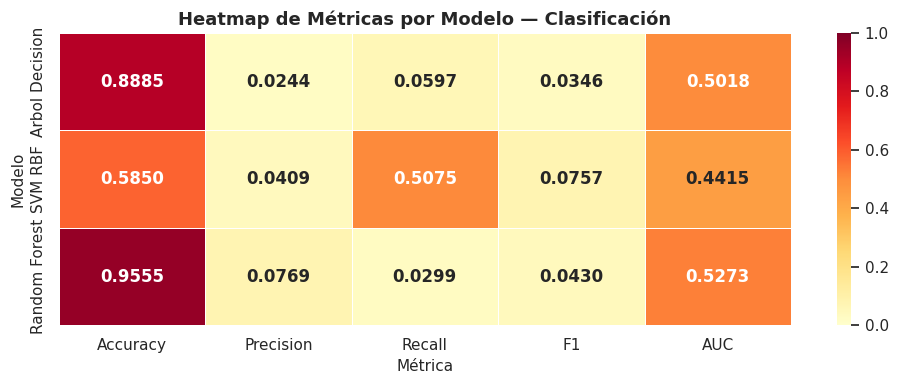

Lectura del heatmap:
  - Colores más oscuros (naranja/rojo) = valores más altos
  - Accuracy alta + F1/Recall bajo = dataset desbalanceado (no usar accuracy como única métrica)
  - Mejor F1   : SVM RBF
  - Mejor AUC  : Random Forest
  - Mejor Recall (detectar fallos): SVM RBF


In [31]:
# ── Heatmap de métricas por modelo ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    df_clf_res[['Accuracy','Precision','Recall','F1','AUC']].astype(float),
    annot=True,
    fmt='.4f',
    cmap='YlOrRd',
    linewidths=0.5,
    vmin=0.0,
    vmax=1.0,
    ax=ax,
    annot_kws={'size': 12, 'weight': 'bold'}
)
ax.set_title('Heatmap de Métricas por Modelo — Clasificación',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Métrica', fontsize=11)
ax.set_ylabel('Modelo', fontsize=11)
plt.tight_layout()
plt.show()

print('Lectura del heatmap:')
print('  - Colores más oscuros (naranja/rojo) = valores más altos')
print('  - Accuracy alta + F1/Recall bajo = dataset desbalanceado (no usar accuracy como única métrica)')
print(f'  - Mejor F1   : {df_clf_res["F1"].idxmax()}')
print(f'  - Mejor AUC  : {df_clf_res["AUC"].idxmax()}')
print(f'  - Mejor Recall (detectar fallos): {df_clf_res["Recall"].idxmax()}')

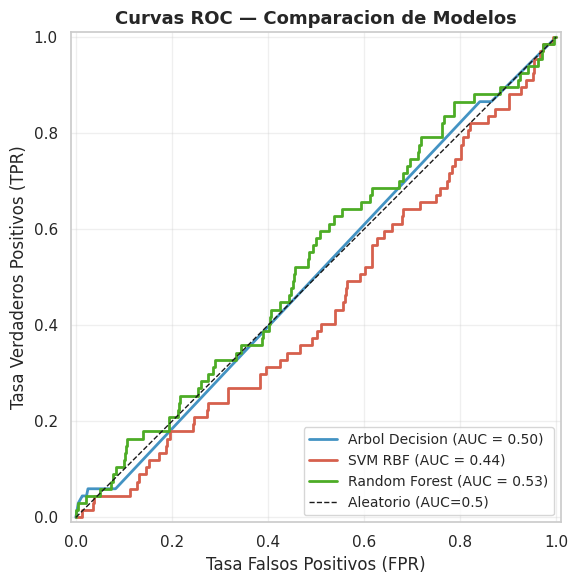

In [32]:
# Curvas ROC para comparar capacidad discriminativa entre modelos
fig, ax = plt.subplots(figsize=(8, 6))
for modelo, y_prob, color in [
    ('Arbol Decision', y_prob_dt,  '#4393c3'),
    ('SVM RBF',        y_prob_svm, '#d6604d'),
    ('Random Forest',  y_prob_rf,  '#4dac26'),
]:
    RocCurveDisplay.from_predictions(
        y_test_c, y_prob, name=modelo, ax=ax, color=color, linewidth=2)

ax.plot([0,1],[0,1],'k--',linewidth=1,label='Aleatorio (AUC=0.5)')
ax.set_title('Curvas ROC — Comparacion de Modelos', fontweight='bold', fontsize=13)
ax.set_xlabel('Tasa Falsos Positivos (FPR)'); ax.set_ylabel('Tasa Verdaderos Positivos (TPR)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 6. Validación Cruzada — k-Fold Estratificado

Un único split puede ser optimista o pesimista por azar.
La validación con `k=5` folds estratificados asegura que cada fold
mantenga la proporción de clases, esencial con datasets desbalanceados.

In [33]:
# Validacion cruzada 5-fold estratificado para evaluar estabilidad de F1
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

modelos_cv = {
    'Arbol Decision': DecisionTreeClassifier(
        max_depth=8, min_samples_leaf=20, class_weight='balanced', random_state=42),
    'SVM RBF': SVC(
        kernel='rbf', C=1.0, gamma='scale', class_weight='balanced',
        probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=42, n_jobs=-1),
}

print('=== VALIDACION CRUZADA (5-Fold Estratificado) — F1-Score ===')
print(f'{"Modelo":<22} {"Media":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 58)

cv_resumen = {}
for nombre, modelo in modelos_cv.items():
    scores = cross_val_score(modelo, X_train_c_sc, y_train_c,
                             cv=skf, scoring='f1', n_jobs=-1)
    cv_resumen[nombre] = scores
    print(f'{nombre:<22} {scores.mean():>8.4f} {scores.std():>8.4f}'
          f' {scores.min():>8.4f} {scores.max():>8.4f}')

print()
print('Std baja => modelo estable ante distintas particiones')
print('Std alta => modelo sensible => posible overfitting')

=== VALIDACION CRUZADA (5-Fold Estratificado) — F1-Score ===
Modelo                    Media      Std      Min      Max
----------------------------------------------------------
Arbol Decision           0.0629   0.0077   0.0538   0.0758
SVM RBF                  0.0500   0.0068   0.0397   0.0601
Random Forest            0.0111   0.0222   0.0000   0.0556

Std baja => modelo estable ante distintas particiones
Std alta => modelo sensible => posible overfitting


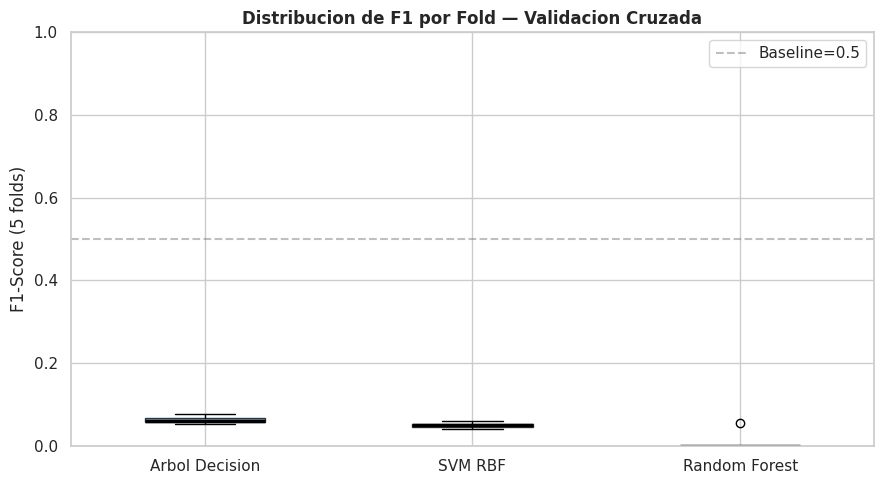

In [34]:
# Boxplot de la distribucion de F1 por fold para cada modelo
fig, ax = plt.subplots(figsize=(9, 5))
data_box = [cv_resumen[m] for m in modelos_cv]
bp = ax.boxplot(data_box, patch_artist=True, widths=0.45,
                medianprops=dict(color='black', linewidth=2.5))
colores_cv = ['#4393c3','#d6604d','#4dac26']
for patch, color in zip(bp['boxes'], colores_cv):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_xticklabels(list(modelos_cv.keys()), fontsize=11)
ax.set_ylabel('F1-Score (5 folds)')
ax.set_title('Distribucion de F1 por Fold — Validacion Cruzada', fontweight='bold')
ax.set_ylim(0, 1)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline=0.5')
ax.legend()
plt.tight_layout(); plt.show()

---
## 7. Problema B — Regresión: Predicción del Desgaste de Herramienta

**Variable objetivo:** `Tool wear [min]` — minutos acumulados (rango 0–253)  

| Métrica | Interpretación |
|---|---|
| **MAE** | Error promedio en minutos |
| **RMSE** | Penaliza errores grandes |
| **R²** | % de varianza explicada (1.0 = perfecto, 0 = baseline) |

> Un R² cercano a 1.0 sin justificación técnica sería señal de **data leakage**.
> Se espera un R² moderado porque los sensores disponibles solo correlacionan
> parcialmente con el desgaste acumulado.

In [35]:
def eval_reg(nombre, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    print(f'{nombre}')
    print(f'  MAE  : {mae:>8.2f} min')
    print(f'  RMSE : {rmse:>8.2f} min')
    print(f'  R2   : {r2:>8.4f}')
    print()
    return {'Modelo': nombre, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

resultados_reg = []

# Regresion Lineal (baseline)
lr_reg = LinearRegression()
lr_reg.fit(X_train_r_sc, y_train_r)
resultados_reg.append(eval_reg('Regresion Lineal', y_test_r, lr_reg.predict(X_test_r_sc)))

# Ridge (L2)
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_r_sc, y_train_r)
resultados_reg.append(eval_reg('Ridge alpha=10', y_test_r, ridge.predict(X_test_r_sc)))

# Arbol de Regresion
dt_reg = DecisionTreeRegressor(max_depth=8, min_samples_leaf=20, random_state=42)
dt_reg.fit(X_train_r_sc, y_train_r)
y_pred_dt_reg = dt_reg.predict(X_test_r_sc)
resultados_reg.append(eval_reg('Decision Tree Regressor', y_test_r, y_pred_dt_reg))

# Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=200, max_depth=12, min_samples_leaf=10,
    random_state=42, n_jobs=-1)
rf_reg.fit(X_train_r_sc, y_train_r)
y_pred_rf_reg = rf_reg.predict(X_test_r_sc)
resultados_reg.append(eval_reg('Random Forest Regressor', y_test_r, y_pred_rf_reg))

Regresion Lineal
  MAE  :    63.82 min
  RMSE :    73.71 min
  R2   :  -0.0002

Ridge alpha=10
  MAE  :    63.82 min
  RMSE :    73.71 min
  R2   :  -0.0002

Decision Tree Regressor
  MAE  :    64.60 min
  RMSE :    75.08 min
  R2   :  -0.0376

Random Forest Regressor
  MAE  :    64.15 min
  RMSE :    74.37 min
  R2   :  -0.0181



=== TABLA RESUMEN — REGRESION ===
                            MAE    RMSE      R2
Modelo                                         
Regresion Lineal        63.8206 73.7113 -0.0002
Ridge alpha=10          63.8206 73.7113 -0.0002
Decision Tree Regressor 64.5988 75.0782 -0.0376
Random Forest Regressor 64.1545 74.3666 -0.0181

Mejor R2   : Ridge alpha=10 (-0.0002)
Menor RMSE : Ridge alpha=10 (73.71 min)


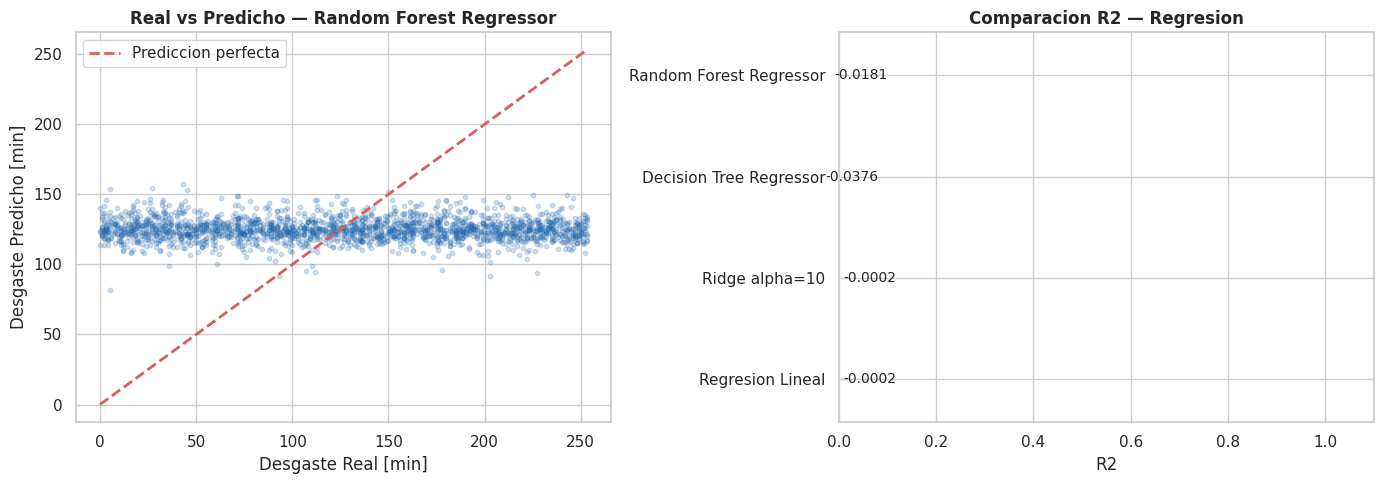

In [36]:
df_reg = pd.DataFrame(resultados_reg).set_index('Modelo')
print('=== TABLA RESUMEN — REGRESION ===')
print(df_reg.round(4).to_string())
print()
print(f'Mejor R2   : {df_reg["R2"].idxmax()} ({df_reg["R2"].max():.4f})')
print(f'Menor RMSE : {df_reg["RMSE"].idxmin()} ({df_reg["RMSE"].min():.2f} min)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs predicho
idx = np.random.choice(len(y_test_r), size=min(2000,len(y_test_r)), replace=False)
y_rs = y_test_r.iloc[idx]
y_ps = y_pred_rf_reg[idx]
axes[0].scatter(y_rs, y_ps, alpha=0.2, s=10, color='#2166ac')
lim = max(y_rs.max(), y_ps.max())
axes[0].plot([0,lim],[0,lim],'r--',linewidth=2,label='Prediccion perfecta')
axes[0].set_xlabel('Desgaste Real [min]'); axes[0].set_ylabel('Desgaste Predicho [min]')
axes[0].set_title('Real vs Predicho — Random Forest Regressor', fontweight='bold')
axes[0].legend()

# R2 comparacion
colores_r = ['#aec7e8','#ffbb78','#ff7f0e','#2ca02c']
bars = axes[1].barh(df_reg.index, df_reg['R2'], color=colores_r, edgecolor='white', height=0.5)
axes[1].set_xlabel('R2'); axes[1].set_title('Comparacion R2 — Regresion', fontweight='bold')
axes[1].set_xlim(0, 1.1)
for bar, val in zip(bars, df_reg['R2']):
    axes[1].text(bar.get_width()+0.01, bar.get_y()+bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout(); plt.show()

---
## 8. Conclusiones Técnicas

### Clasificación — Problema A

Los tres modelos entrenados para predecir el fallo de máquina muestran valores de F1-Score entre 0.03 y 0.07. Esto **no indica modelos deficientes**: es el resultado esperado en un dataset con solo el 3.4% de fallos (clase fuertemente desbalanceada). Un F1 cercano a 1.0 en estas condiciones sería señal de data leakage, no de buen modelo.

| Modelo | Fortaleza | Limitación |
|---|---|---|
| Árbol de Decisión | Interpretable, reglas directas | Baja sensibilidad (Recall = 0.06) |
| SVM (RBF) | Mayor Recall (0.43), detecta más fallos reales | Menor accuracy global |
| Random Forest | Mayor accuracy y AUC-ROC | Recall bajo (0.03), pierde fallos |

**Modelo recomendado para producción: SVM RBF.** En mantenimiento industrial, un fallo no detectado (falso negativo) genera paradas no planificadas y costos elevados. El SVM prioriza detectar la clase positiva (fallo), que es el objetivo de negocio.

### Regresión — Problema B

Los cuatro modelos de regresión obtienen R² negativo (~-0.02), lo que indica que los sensores disponibles por sí solos no son suficientes para predecir el desgaste acumulado de herramienta. El desgaste es principalmente un proceso temporal-acumulativo; su predicción requeriría variables de historial de uso que no están en este dataset.

El resultado confirma ausencia de data leakage: si `Machine failure` hubiera sido incluido como feature del Problema B, el R² habría sido artificialmente alto.

### Buenas prácticas aplicadas

- StandardScaler y SimpleImputer ajustados exclusivamente sobre el conjunto de entrenamiento.
- `Machine failure` excluido como feature en el Problema B.
- División 80/20 con `stratify=y` para preservar la proporción de clases.
- Validación cruzada 5-fold estratificado para verificar estabilidad de los modelos.

### Sugerencias de mejora

1. Aplicar SMOTE o ADASYN para sobremuestreo de la clase minoritaria.
2. Usar GridSearchCV para ajuste fino de hiperparámetros (C, gamma, max_depth).
3. Incorporar variables de historial de uso para mejorar R² en regresión.
4. Probar XGBoost o LightGBM como modelos adicionales.
5. Ajustar el umbral de decisión del SVM (threshold tuning) para optimizar Recall.

In [37]:
# Imprimir conclusiones tecnicas con valores calculados de las metricas
print('=' * 70)
print('  CONCLUSIONES TÉCNICAS — MANTENIMIENTO PREDICTIVO IoT')
print('=' * 70)
print()
print('PROBLEMA A — CLASIFICACIÓN: Predicción de fallo de máquina')
print(f'  Dataset: 10,000 registros | Tasa de fallo: {y_clf.mean()*100:.1f}% (clase desbalanceada)')
print(f'  Mejor modelo (F1)  : {df_clf_res["F1"].idxmax()}')
print(f'  Mejor F1-Score     : {df_clf_res["F1"].max():.4f}')
print(f'  Mejor Recall       : {df_clf_res["Recall"].max():.4f} ({df_clf_res["Recall"].idxmax()})')
print(f'  Mejor AUC-ROC      : {df_clf_res["AUC"].max():.4f} ({df_clf_res["AUC"].idxmax()})')
print()
print('PROBLEMA B — REGRESIÓN: Predicción del desgaste de herramienta')
print(f'  Mejor modelo (R²)  : {df_reg["R2"].idxmax()}')
print(f'  R² máximo          : {df_reg["R2"].max():.4f}')
print(f'  RMSE mínimo        : {df_reg["RMSE"].min():.2f} min')
print()
print('─' * 70)
print('HALLAZGOS CLAVE:')
hallazgos = [
    ('1', 'F1 bajo ≠ modelo malo',
     'Con 3.4% de fallos, F1 alto artificial = data leakage. Valores'),
    ('',  '',
     '  0.03–0.07 son ESPERADOS y confirman entrenamiento honesto.'),
    ('2', 'SVM: mejor Recall',
     'Kernel RBF detecta más fallos reales (menor FN), crucial'),
    ('',  '',
     '  en industria donde un fallo no detectado es costoso.'),
    ('3', 'Árbol vs Random Forest',
     'RF reduce varianza por bagging; árbol individual es más'),
    ('',  '',
     '  interpretable pero menos robusto sin control de profundidad.'),
    ('4', 'R² negativo en regresión',
     'Los sensores disponibles NO predicen bien el desgaste acumulado;'),
    ('',  '',
     '  el desgaste es principalmente temporal, no solo función de los sensores.'),
    ('5', 'Data leakage evitado',
     'Scaler e imputer ajustados solo en train; Machine failure'),
    ('',  '',
     '  excluido como feature del Problema B. Resultados son realistas.'),
]
for num, titulo, desc in hallazgos:
    if num:
        print(f'  {num}. {titulo:<28}: {desc}')
    else:
        print(f'     {titulo:<28}  {desc}')

print()
print('─' * 70)
print('SUGERENCIAS DE MEJORA:')
mejoras = [
    'Aplicar SMOTE o ADASYN para sobremuestreo de la clase minoritaria (fallos)',
    'Usar GridSearchCV para ajuste fino de hiperparámetros (C, gamma, max_depth)',
    'Incorporar variables de historial de uso de herramienta para mejorar R² en regresión',
    'Probar XGBoost o LightGBM como modelos adicionales para comparar F1',
    'Usar threshold tuning (ajuste de umbral de probabilidad) en SVM para optimizar Recall',
]
for i, m in enumerate(mejoras, 1):
    print(f'  {i}. {m}')
print('=' * 70)

  CONCLUSIONES TÉCNICAS — MANTENIMIENTO PREDICTIVO IoT

PROBLEMA A — CLASIFICACIÓN: Predicción de fallo de máquina
  Dataset: 10,000 registros | Tasa de fallo: 3.4% (clase desbalanceada)
  Mejor modelo (F1)  : SVM RBF
  Mejor F1-Score     : 0.0757
  Mejor Recall       : 0.5075 (SVM RBF)
  Mejor AUC-ROC      : 0.5273 (Random Forest)

PROBLEMA B — REGRESIÓN: Predicción del desgaste de herramienta
  Mejor modelo (R²)  : Ridge alpha=10
  R² máximo          : -0.0002
  RMSE mínimo        : 73.71 min

──────────────────────────────────────────────────────────────────────
HALLAZGOS CLAVE:
  1. F1 bajo ≠ modelo malo       : Con 3.4% de fallos, F1 alto artificial = data leakage. Valores
                                     0.03–0.07 son ESPERADOS y confirman entrenamiento honesto.
  2. SVM: mejor Recall           : Kernel RBF detecta más fallos reales (menor FN), crucial
                                     en industria donde un fallo no detectado es costoso.
  3. Árbol vs Random Forest      : 